Claro, podemos expandir el análisis de comparación mesa por mesa con elecciones anteriores de la siguiente manera:

### 2. Comparación Mesa por Mesa con Elecciones Anteriores

#### Objetivos:
1. **Identificar Cambios en la Preferencia Electoral**: Analizar cómo los votos para cada partido o candidato han cambiado en cada mesa desde la última elección.
2. **Detectar Patrones Geográficos**: Examinar si los cambios en la votación se concentran en áreas específicas.
3. **Evaluar la Efectividad de Estrategias de Campaña**: Determinar si los esfuerzos de campaña han tenido un impacto positivo en áreas clave.
4. **Predecir Tendencias Futuras**: Utilizar los cambios observados para prever posibles tendencias en futuras elecciones.

#### Datos Necesarios:
- Resultados electorales por mesa de varias elecciones.
- Información geográfica de las mesas electorales.

#### Estructura de Datos:
- Columnas: ID de Mesa, Año de Elección, Partido/Candidato 1, Partido/Candidato 2, ..., Votos Totales
- Filas: Cada fila representa una mesa en una elección específica.


#### Indicadores y Análisis:

1. **Variación de Votos**:
   - Cálculo de la diferencia absoluta y relativa de votos para cada partido entre elecciones.
   - Identificación de mesas con mayores incrementos o decrementos de votos.

2. **Concentración Geográfica de Cambios**:
   - Análisis espacial para identificar áreas con cambios significativos en la votación.
   - Utilización de mapas de calor o mapas temáticos para visualizar estas áreas.

5. **Comparación con Resultados a Nivel Nacional o Regional**: (mesas anomalas)
   - Comparación de las tendencias observadas a nivel de mesa con las tendencias a nivel nacional o regional.
   - Identificación de áreas donde los cambios locales divergen significativamente de las tendencias más amplias.

6. **Identificación de Factores Clave de Cambio**:
   - Análisis para determinar qué factores han sido más influyentes en los cambios observados.

7. **Evaluación de la Efectividad de Estrategias de Campaña**:
   - Identificación de estrategias de campaña que parecen haber sido más efectivas.

8. **Visualización de Resultados**:
   - Utilización de gráficos y mapas para presentar los resultados de manera clara y comprensible.


In [ ]:
# path_datosBD = '/content/drive/My Drive/electoral/datos/BD'
path_datos = './../../datos'



### 2. Preparación de Datos
   - **Carga de Datos**: Importar los datos electorales necesarios para el análisis.

In [ ]:
import pandas as pd

In [ ]:
# pd.read_csv(path_datosBD+'/seccion_table.csv')

In [ ]:
# df_mesas = pd.read_csv(path_datos+'/BD151923/mesas_table.csv')


### 2. Preparación de Datos

#### Carga de Datos:
- Se cargan los datos de votación de diferentes elecciones y otros archivos relacionados con la elección, como listas de agrupaciones y claves de departamentos.
- Se concatenan los DataFrames de diferentes elecciones y se filtran según los cargos electivos.



In [ ]:
import pandas as pd
# # ----- Data Loading -----

# Define the path to your data
# path_datosBD = "./your/data/path"
# path_datos = '/content/drive/My Drive/electoral/datos'
path_datos = './../../datos'

# Define the cargo IDs you are interested in
cargo_ids = [1, 3, 4]

# List of election files
election_files = ['votos_eleccion_7_table.csv', 'votos_eleccion_8_table.csv'] # df23PASO, df23GRAL

# Load and filter the data in a single line
df = pd.concat([pd.read_csv(f"{path_datos}/BD151923/{file_name}", dtype={'agrupacion_id': str}).query("cargo_id in @cargo_ids") for file_name in election_files], axis=0)


In [ ]:


# df23PASO = pd.read_csv(path_datosBD + '/votos_eleccion_17_table.csv')
# df23GRAL = pd.read_csv(path_datosBD + '/votos_eleccion_18_table.csv')
# df = pd.concat([df23PASO, df23GRAL], axis=0)
# df = df.loc[(df.cargo_id.isin([1, 3, 4]))]

cargo = pd.read_csv(path_datos + '/BD151923/cargo_tags.csv')
agrup_lista = pd.read_csv(path_datos + '/BD151923/agrupacion_lista_table.csv')
agrup_nombre = pd.read_csv(path_datos + '/BD151923/agrupacion_nombre_table.csv')
agrup_nombre['agrupacion_id'] = agrup_nombre['agrupacion_id'].fillna('000000')#, dtype={'agrupacion_id': str}) ## agrupacion nombres
claves_dptos = pd.read_csv(path_datos + '/BD151923/claves_dptos_ref.csv')
eleccion_tags = pd.read_csv(path_datos + '/BD151923/eleccion_tags.csv')
prov_nams = pd.read_csv(path_datos + '/BD151923/distrito_table.csv')



#### Limpieza de Datos:
- Se realizan transformaciones en los IDs de agrupación y números de lista para armonizarlos y asegurar consistencia.
- Se limpian y armonizan los nombres de las agrupaciones.


In [ ]:
import pandas as pd

# ----- Function Definitions -----
# def harmonize_agrupacion_id(agrupacion_id):
#     if pd.isna(agrupacion_id):
#         return "000000"
#     else:
#         try:
#             return str(int(float(agrupacion_id))).zfill(6)
#         except ValueError:
#             return agrupacion_id

def harmonize_agrupacion_names(df, col_name='agrupacion_nombre'):
    """Harmonizes the names of agrupaciones."""
    replacements = {
        'CAMBIEMOS BUENOS AIRES': 'CAMBIEMOS',
        'JUNTOS': 'JUNTOS POR EL CAMBIO'
    }
    df[col_name] = df[col_name].replace(replacements).str.title().str.strip()
    return df


In [ ]:

# Agrup Nombre Data Preprocessing
# agrup_nombre['agrupacion_id'] = agrup_nombre['agrupacion_id'].apply(harmonize_agrupacion_id)
merged_data = df.merge(agrup_nombre)
merged_data = harmonize_agrupacion_names(merged_data)


In [ ]:

# # # Agrup Lista Data Preprocessing
# # agrup_lista['agrupacion_id'] = agrup_lista['agrupacion_id'].apply(harmonize_agrupacion_id)
# # agrup_lista['lista_numero'] = agrup_lista['lista_numero'].apply(harmonize_agrupacion_id)


# # ----- Data Merging & Transformations -----
# # Merge with simil_nombre
# simil_nombre = agrup_lista.groupby(['eleccion_id', 'distrito_id', 'agrupacion_id']).agrupacion_nombre.first().reset_index()
# df['agrupacion_id'] = df['agrupacion_id'].astype(str).str.zfill(6)
# merged_data = df.merge(simil_nombre)
# merged_data = harmonize_agrupacion_names(merged_data)
# # display(merged_data)


In [ ]:
merged_data.head()


#### Verificación de Datos:
- Aunque no se muestra explícitamente en el código proporcionado, se asume que las operaciones de fusión, agrupación y transformación de datos forman parte del proceso de verificación de datos para asegurarse de que están estructurados correctamente y listos para el análisis.

**Agrupa en Nivel Circuitos**

In [ ]:

# Group and aggregate data
# aggregated_data = merged_data.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre', 'lista_numero', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).reset_index()
aggregated_data = merged_data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).unstack()#.reset_index()
display(aggregated_data)

In [ ]:
aggregated_data.loc[7] - aggregated_data.loc[8]

In [ ]:
# aggregated_data = merged_data.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).reset_index()


In [ ]:

# # Top N aggregation
# N = 20
# top_aggregated_data = aggregated_data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo'])\
#                                      .apply(lambda x: x.nlargest(N, 'votos_cantidad'))\
#                                      .reset_index(drop=True).rename(columns={'votos_cantidad': 'votos_nacional'})
# # display(top_aggregated_data)


In [ ]:

# # Further transformations on original data
# data_copy = merged_data.copy()
# data_copy = data_copy.merge(top_aggregated_data, how='left')
# data_copy['agrupacion_nombre_'] = data_copy['agrupacion_nombre'].mask(data_copy['votos_nacional'].isnull(), 'Resto')


In [ ]:

# # data_aggregated = data_copy.groupby(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre_', 'lista_numero', 'votos_tipo', 'eleccion_id'])\
# data_aggregated = data_copy.groupby(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre_', 'votos_tipo', 'eleccion_id'])\
#                            .agg({'votos_cantidad': 'sum'}).reset_index()



## Analisis Mesa por Mesa

In [ ]:
# pivot = data_aggregated.set_index(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre', 'votos_tipo', 'eleccion_id']).unstack().reset_index()

data_aggregated = merged_data.groupby(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre', 'votos_tipo', 'eleccion_id'])\
                           .agg({'votos_cantidad': 'sum'}).reset_index()

In [ ]:
pivot = data_aggregated.pivot_table(index=['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre', 'votos_tipo'],
                                    columns='eleccion_id',
                                    values='votos_cantidad',  # assuming 'votos_cantidad' is the column you want to reshape
                                    aggfunc='sum')  # or another aggregation function if needed
pivot.reset_index(inplace=True)


In [ ]:
pivot.head()

In [ ]:
x = pivot.groupby(['cargo_id', 'agrupacion_nombre'])[[7, 8]].sum()
# x

In [ ]:
x.loc[x.sum(1) > 5e5].diff(-1, axis = 1)

In [ ]:
pivot['diff'] = pivot[[7, 8]].diff(-1, axis = 1).iloc[:, 0].values

In [ ]:
x = pivot.loc[pivot['cargo_id'] == 1].groupby(['distrito_id', 'agrupacion_nombre'])[['diff']].sum()
# swap columns level
x = x.unstack(0).swaplevel(axis = 1)
x = x.sort_index(axis = 1, level = 0)
(x.loc[abs(x.sum(1)) > 1e4].T/1e3).round(-1).astype(int)

In [ ]:
claves_dptos

In [ ]:
x = pivot.loc[pivot['cargo_id'] == 1].groupby(['distrito_id', 'seccion_id', 'agrupacion_nombre'])[['diff']].sum()
# swap columns level
x = x.unstack([0, 1]).swaplevel(axis = 1)
x = x.sort_index(axis = 1, level = 0)
# x = x.reindex(abs(x.sum(1)).sort_values())

(x.loc[abs(x.sum(1)) > 1e3].T/1e3).round().astype(int).sort_values(['La Libertad Avanza']).tail(30).reset_index().merge(claves_dptos)

In [ ]:
pivot.loc[pivot['cargo_id'] == 1].sort_values('diff', ascending=False).head(20)

In [ ]:
pivot[[7, 8]].head().sum()

In [ ]:
merged_data['circuito_id'] = merged_data['circuito_id'].astype(str).str.zfill(6)

In [ ]:
# pivot = data_aggregated.set_index(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre', 'votos_tipo', 'eleccion_id']).unstack().reset_index()

data_aggregated = merged_data.groupby(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'cargo_id', 'agrupacion_nombre', 'votos_tipo', 'eleccion_id'])\
                           .agg({'votos_cantidad': 'sum'}).reset_index()

In [ ]:
pivot = data_aggregated.pivot_table(index=['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id', 'votos_tipo'],
                                    columns=['cargo_id', 'eleccion_id', 'agrupacion_nombre'],
                                    values='votos_cantidad',  # assuming 'votos_cantidad' is the column you want to reshape
                                    aggfunc='sum')  # or another aggregation function if needed
pivot#.reset_index(inplace=True)


In [ ]:
pivot.loc[1, 12].dropna(axis = 0, how = 'all').dropna(axis = 1, how = 'all')

In [ ]:
mesas = pd.read_csv('./../../datos/BD151923/mesas_table.csv')

In [ ]:
pivot[1].head().columns

ppales = pivot[1][8].sum().sort_values().tail(5).index.values
ppales

dsPpre = pivot[1][8][ppales]#.dropna(how = 'all')
dsGpre = pivot[1][7][ppales]#.dropna(how = 'all')

In [ ]:
## Agregar Columna 'No votaron'
dsGpre_reset = dsGpre.reset_index()
merged_df = mesas.loc[mesas.eleccion_id == 7].merge(dsGpre_reset, left_on=['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id'], right_on=['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id'])
merged_df = merged_df.drop(['mesa_tipo', 'votos_tipo', 'eleccion_id'], axis = 1).set_index(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id'])

merged_df['no_votaron'] = merged_df.mesa_electores - merged_df.drop('mesa_electores', axis = 1).sum(1)
merged_df = merged_df.drop('mesa_electores', axis = 1)

dsGpre = merged_df


## Agregar Columna 'No votaron'
dsPpre_reset = dsPpre.reset_index()
merged_df = mesas.loc[mesas.eleccion_id == 7].merge(dsPpre_reset, left_on=['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id'], right_on=['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id'])
merged_df = merged_df.drop(['mesa_tipo', 'votos_tipo', 'eleccion_id'], axis = 1).set_index(['distrito_id', 'seccion_id', 'circuito_id', 'mesa_id'])

merged_df['no_votaron'] = merged_df.mesa_electores - merged_df.drop('mesa_electores', axis = 1).sum(1)
merged_df = merged_df.drop('mesa_electores', axis = 1)

dsPpre = merged_df

In [ ]:
# Expresar como fracciones:

dsPpre = dsPpre.div(dsPpre.sum(1), axis = 0)
dsGpre = dsGpre.div(dsGpre.sum(1), axis = 0)

In [ ]:
dsGpre

In [283]:
import numpy as np

dsPpre_matrix = dsPpre.to_numpy()
dsGpre_matrix = dsGpre.to_numpy()

newdata = np.hstack([dsPpre_matrix, dsGpre_matrix])


In [284]:
dsGpre.head()

Frente De Izquierda Y De Trabajadores - Unidad  \
distrito_id seccion_id circuito_id mesa_id                                                   
2           1          000001      1                                              0.022857   
                                   2                                              0.011461   
                                   3                                              0.008621   
                                   4                                              0.020000   
                                   5                                              0.022792   

                                            Hacemos Por Nuestro Pais  \
distrito_id seccion_id circuito_id mesa_id                             
2           1          000001      1                        0.051429   
                                   2                        0.028653   
                                   3                        0.051724   
                                   4                        0.028571   
                                   5                        0.039886   

                                            Union Por La Patria  \
distrito_id seccion_id circuito_id mesa_id                        
2           1          000001      1                   0.191429   
                                   2                   0.183381   
                                   3                   0.183908   
                                   4                   0.200000   
                                   5                   0.276353   

                                            Juntos Por El Cambio  \
distrito_id seccion_id circuito_id mesa_id                         
2           1          000001      1                    0.260000   
                                   2                    0.326648   
                                   3                    0.278736   
                                   4                    0.277143   
                                   5                    0.139601   

                                            La Libertad Avanza  no_votaron  
distrito_id seccion_id circuito_id mesa_id                                  
2           1          000001      1                  0.228571    0.245714  
                                   2                  0.186246    0.263610  
                                   3                  0.238506    0.238506  
                                   4                  0.217143    0.257143  
                                   5                  0.193732    0.327635

In [285]:
dsPpre.head()

Frente De Izquierda Y De Trabajadores - Unidad  \
distrito_id seccion_id circuito_id mesa_id                                                   
2           1          000001      1                                              0.002857   
                                   2                                              0.002865   
                                   3                                              0.000000   
                                   4                                              0.002857   
                                   5                                              0.005698   

                                            Hacemos Por Nuestro Pais  \
distrito_id seccion_id circuito_id mesa_id                             
2           1          000001      1                        0.005714   
                                   2                        0.005731   
                                   3                        0.017241   
                                   4                        0.008571   
                                   5                        0.014245   

                                            Union Por La Patria  \
distrito_id seccion_id circuito_id mesa_id                        
2           1          000001      1                   0.168571   
                                   2                   0.163324   
                                   3                   0.152299   
                                   4                   0.145714   
                                   5                   0.245014   

                                            Juntos Por El Cambio  \
distrito_id seccion_id circuito_id mesa_id                         
2           1          000001      1                    0.237143   
                                   2                    0.363897   
                                   3                    0.353448   
                                   4                    0.322857   
                                   5                    0.182336   

                                            La Libertad Avanza  no_votaron  
distrito_id seccion_id circuito_id mesa_id                                  
2           1          000001      1                  0.174286    0.411429  
                                   2                  0.146132    0.318052  
                                   3                  0.160920    0.316092  
                                   4                  0.134286    0.385714  
                                   5                  0.153846    0.398860

Funcion `call_difp`

- $ \mathbf{mx} $: This is the matrix of independent variables or predictors. Each row represents a different observation, and each column represents a different variable.
- $ \mathbf{my} $: This is the matrix of dependent variables or responses. Each row corresponds to the values of the dependent variables for a particular observation. 

Given this context, we can express the operations performed in the function in a more mathematical form.

### Objective Function

The function is calculating a penalized least squares criterion. The formula for this can be expressed as:

$$
J(\mathbf{p}) = \|\mathbf{MX}\mathbf{P} - \mathbf{MY}\|^2_2 + \lambda \|\mathbf{p}\|^2_2
$$

where:
- $ \mathbf{P} $ is the parameter matrix, reshaped from the parameter vector $ \mathbf{p} $.
- $ \mathbf{MX} $ is the matrix of independent variables.
- $ \mathbf{MY} $ is the matrix of dependent variables.
- $ \|\cdot\|^2_2 $ denotes the squared Frobenius norm (sum of squares of all elements).
- $ \lambda $ is the regularization constant (denoted as `const` in the code).

### Calculation Steps

1. **Reshape Parameters**: 
   $$
   \mathbf{P} = \text{reshape}(\mathbf{p}, (nR, nC))
   $$
2. **Calculate Predicted Values**: 
   $$
   \hat{\mathbf{Y}} = \mathbf{MX} \cdot \mathbf{P}
   $$
3. **Calculate Squared Error**: 
   $$
   \text{Error} = \|\hat{\mathbf{Y}} - \mathbf{MY}\|^2_2
   $$
4. **Add Penalty Term**: 
   $$
   \text{Penalty} = \lambda \|\mathbf{p}\|^2_2
   $$
5. **Calculate Total Loss**: 
   $$
   J(\mathbf{p}) = \text{Error} + \text{Penalty}
   $$

The goal of the optimization algorithm is to find the value of $ \mathbf{p} $ that minimizes the total loss $ J(\mathbf{p}) $. This involves balancing fitting the model to the data (minimizing the squared error) and keeping the parameters small to avoid overfitting (minimizing the penalty term).

In [ ]:
from scipy.optimize import minimize

def call_difp(p, mx, my, nR, nC, const):
    print("Shape of p:", p.shape)
    print("p:", p)
    print("nR:", nR)
    print("nC:", nC)
    # print("Shape of mx:", mx.shape)
    print("mx:", mx)
    # print("Shape of my:", my.shape)
    print("my:", my)

    try:
        # Attempt to reshape and calculate the predicted values
        p_reshaped = p[:nR*(nC)].reshape(nR, nC)
        print("Shape of p_reshaped:", p_reshaped.shape)
        print("p_reshaped:", p_reshaped)
        predicted = np.dot(mx, p_reshaped)
        print("Shape of predicted:", predicted.shape)
        print("predicted:", predicted)
    except Exception as e:
        print("Error during calculation:", e)
        return np.inf  # Return infinity to indicate an error in calculation

    # Calculating the squared error
    error = np.sum((predicted - my) ** 2)
    print("error:", error)
    
    # Adding the penalty term
    penalty = const * np.sum(p ** 2)
    print("penalty:", penalty)
    
    total = error + penalty
    print("total:", total)
    return total

def params_estim(data, x=-1, nR=None, nC=None, const=0.001, parSeed=-1):
    if x == -1:
        x = np.arange(data.shape[0])
    
    print("Data shape:", data.shape)
    print("nR:", nR)
    print("nC:", nC)
    
    mx = data[x, :nR]
    my = data[x, nR:nR+nC]
    nP = data.shape[0]
    covar = False
    
    print("mx shape:", mx.shape)
    print("my shape:", my.shape)
    
    if data.shape[1] > nR + nC:
        covar = data[x, nR+nC+1]
        if parSeed == -1:
            parSeed = np.random.normal(size=2*nR*(nC-1))
    else:
        if parSeed == -1:
            parSeed = np.random.normal(size=nR*(nC-1))
                                                p, mx, my, covar, nR, nC, nP, const)
    result = minimize(call_difp, parSeed, args=(covar, nR, nC, nP, mx, my, const), method="L-BFGS-B")
    
    return result.x


In [314]:
from scipy.optimize import minimize
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

def call_difp(p, mx, my, nR, nC, const):
    # print("Shape of p:", p.shape)
    # print("p:", p)
    # print("nR:", nR)
    # print("nC:", nC)
    # print("mx:", mx)
    # print("my:", my)

    try:
        # Attempt to reshape and calculate the predicted values
        # p_reshaped = p[:nR * nC].reshape(nR, nC)
        p_reshaped = softmax(p.reshape(nR, nC))

        print("Shape of p_reshaped:", p_reshaped.shape)
        # print("p_reshaped:", p_reshaped)
        predicted = np.dot(mx, p_reshaped)
        print("Shape of predicted:", predicted.shape)
        # print("predicted:", predicted)
    except Exception as e:
        print("Error during calculation:", e)
        return np.inf  # Return infinity to indicate an error in calculation

    # Calculating the squared error
    error = np.sum((predicted - my) ** 2)
    print("error:", error)
    
    # Adding the penalty term
    penalty = const * np.sum(p ** 2)
    print("penalty:", penalty)
    
    total = error + penalty
    print("total:", total)
    return total

def params_estim(data, frac=None, nR=None, nC=None, const=0.001, parSeed=-1):
    if frac is not None:
        if 0 < frac < 1:
            sample_size = int(len(data) * frac)
            sampled_indices = np.random.choice(len(data), sample_size, replace=False)
            data = data[sampled_indices]
        else:
            raise ValueError("frac must be between 0 and 1")


    # Define bounds for each parameter
    bounds = [(0, 1) for _ in range(nR * nC)]

    if nR is None or nC is None:
        raise ValueError("nR and nC must be specified")

    mx = data[:, :nR]
    my = data[:, nR:nR+nC]
    
    if parSeed == -1:
        # Initialize parSeed as a flattened identity matrix of shape (nR, nC-1)
        parSeed = np.eye(nR, nC).flatten()

    # Call the optimization function
    result = minimize(call_difp, parSeed, args=(mx, my, nR, nC, const), method="L-BFGS-B")#, bounds=bounds)
    final_parameters = softmax(result.x.reshape(nR, nC))
    # final_parameters = result.x
    return final_parameters


In [315]:
newdata = pd.DataFrame(newdata).dropna().values

In [316]:

# Running the parameter estimation function
params = params_estim(newdata, frac=0.5, nR=6, nC=6)
print("Estimated Parameters:", params)



Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.14922090642585
penalty: 0.006
total: 356.1552209064258
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.14922096234045
penalty: 0.00600000002
total: 356.15522096236043
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.1492209226265
penalty: 0.006
total: 356.1552209226265
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.14922087406126
penalty: 0.006
total: 356.15522087406123
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.14922089868753
penalty: 0.006
total: 356.1552208986875
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.1492208912787
penalty: 0.006
total: 356.15522089127865
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.1492208895605
penalty: 0.006
total: 356.1552208895605
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 356.1492209479951
penalty: 0.006
total: 356.1552209479951
S

error: 111.81040707294454
penalty: 0.08681860420026538
total: 111.8972256771448
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 111.81040707751634
penalty: 0.08681860419650457
total: 111.89722568171285
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 111.81040708252742
penalty: 0.08681860428388416
total: 111.8972256868113
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 111.81040707411981
penalty: 0.08681860421693972
total: 111.89722567833675
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 111.81040706566066
penalty: 0.08681860425393047
total: 111.89722566991459
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 111.81040707296353
penalty: 0.08681860418758569
total: 111.89722567715111
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 111.81040707048112
penalty: 0.08681860420825069
total: 111.89722567468937
Shape of p_reshaped: (6, 6)
Shape of predicted: (5225, 6)
error: 111.81040708033936
pen

Estimated Parameters:


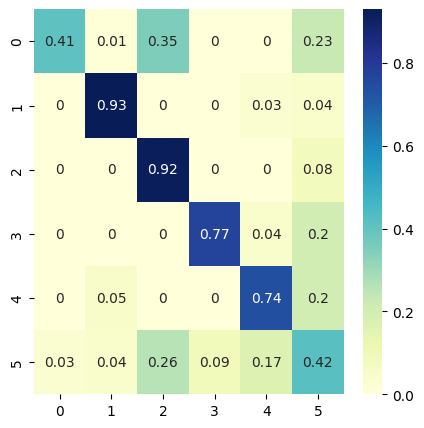

In [317]:
print("Estimated Parameters:")


vals = params.round(2).reshape(6, 6)


# matrix plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.heatmap(vals, annot=True, cmap="YlGnBu", fmt='g')
plt.show()


In [307]:
vals.sum(0)

array([0.58, 1.1 , 1.57, 0.89, 1.06, 1.15])

In [ ]:
import numpy as np

data = newdata  # Replace with your data
# x = -1
frac = .2
nR = 6  # Set the correct number of rows
nC = 6  # Set the correct number of columns
const = 0.001
parSeed = -1


if frac is not None:
    if 0 < frac < 1:
        sample_size = int(len(data) * frac)
        sampled_indices = np.random.choice(len(data), sample_size, replace=False)
        data = data[sampled_indices]
    else:
        raise ValueError("frac must be between 0 and 1")

nP, total_cols = data.shape
if nR is None or nC is None:
    raise ValueError("nR and nC must be specified")

mx = data[:, :nR]
my = data[:, nR:nR+nC]
covar = False

if total_cols > nR + nC:
    covar = data[:, nR+nC]
    if parSeed == -1:
        # Initialize parSeed as a flattened identity matrix of shape (nR, nC-1)
        parSeed = np.eye(nR, nC).flatten()
else:
    if parSeed == -1:
        # Initialize parSeed as a flattened identity matrix of shape (nR, nC-1)
        parSeed = np.eye(nR, nC).flatten()


In [ ]:
mx

In [ ]:
np.eye(nR, nC)#.flatten()

In [ ]:
result = minimize(call_difp, parSeed, args=(covar, nR, nC, nP, mx, my, const), method="L-BFGS-B")
print(result)

In [ ]:
estsPG = params_estim(newdata, nR=552, nC=12)


In [ ]:
######################
##
## Cerrar Funcion
##
######################

#Paso a General
newdata<-as.matrix(cbind(dsPpre,dsGpre))
estsPG<-params.estim(newdata,nR=11,nC=7) #10 filas (1 para blancos/ausentes), 3 cols (1 para blancos/ausentes)
fracsPG<-calc.fractions(estsPG,nR=11,nC=7)
colnames(fracsPG)<-colnames(dsGpre)
rownames(fracsPG)<-colnames(dsPpre)

##Datos Summary
VotosPaso <- data1[,5:14]
VotosPaso <- cbind(VotosPaso,data1[,15]-rowSums(VotosPaso))
VotosGeneral <- data1[,16:21]
VotosGeneral <- cbind(VotosGeneral ,data1[,15]-rowSums(VotosGeneral))
colnames(VotosPaso)<-colnames(dsPpre)
colnames(VotosGeneral)<-colnames(dsGpre)


tabla <- round(fracsPG*colSums(VotosPaso),0)

In [ ]:
xx

In [ ]:

# More transformations...
# data_circ = data_aggregated.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre_', 'lista_numero', 'votos_tipo', 'distrito_id', 'seccion_id', 'circuito_id'])[['votos_cantidad']].sum()
data_circ = data_aggregated.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre_', 'votos_tipo', 'distrito_id', 'seccion_id', 'circuito_id'])[['votos_cantidad']].sum()
data_circ = data_circ.reset_index()
data_circ = data_circ.merge(eleccion_tags).merge(cargo)



In [ ]:

# Group by 'eleccion_tag', 'cargo_tag', and 'in1_& (df.distrito_id == 2)prov', and calculate the sum of 'votos_cantidad', divide for PCT
sum_votes = data_circ.groupby(['eleccion_tag', 'cargo_tag', 'distrito_id', 'seccion_id', 'votos_tipo', 'circuito_id'])['votos_cantidad'].transform('sum')
data_circ['votos_porcentaje'] = data_circ['votos_cantidad'] / sum_votes
votos_agrup_circ = data_circ.reset_index(drop = True)

# votos_agrup_lista_circ.to_csv('./../datos/out/votos_agrup_lista_circ.csv', index = False)

# votos_agrup_lista_circ = pd.read_csv('./../datos/out/votos_agrup_lista_circ.csv')



### 3. Análisis Exploratorio de Datos (EDA)

#### Resumen Estadístico:
- No se proporciona un resumen estadístico explícito de los datos en el código proporcionado.

#### Visualización de Datos:
- No se incluyen visualizaciones de datos en el código proporcionado.

#### Identificación de Tendencias:
- Se identifican las agrupaciones y listas principales en términos de votos.



In [ ]:
path_datos = './../../datos'

In [ ]:

# --- Load Data ---
print("Loading data...")

# Load necessary datasets
radio_region = pd.read_csv(path_datos + '/info/radio_ref.csv', usecols=['radio', 'NOMDPTO', 'Region'])
radios_circuitos_secciones = pd.read_csv(path_datos + '/info/radios_circuitos_secciones_ref.csv')[['COD_2010', 'distrito_id', 'seccion_id', 'seccion_nombre']]
prov_nams = pd.read_csv(path_datos + '/BD151923/distrito_table.csv')

# --- Data Preprocessing ---
print("Processing data...")

# Radio region processing
radio_region['COD_2010'] = radio_region['radio'].astype(str).str.zfill(9)

# Merge data
merge_data = radios_circuitos_secciones.merge(radio_region, on='COD_2010', how='left')
seccion_region = merge_data.drop(['COD_2010', 'radio'], axis=1).drop_duplicates()
seccion_region = seccion_region.groupby(['distrito_id', 'seccion_id', 'seccion_nombre']).first().reset_index()

# Votos agrup processing
votos = votos_agrup_circ
# data_circ_ix = votos.set_index(['distrito_id', 'seccion_id', 'circuito_id', 'eleccion_tag', 'cargo_tag', 'agrupacion_nombre_', 'lista_numero', 'votos_tipo'])
data_circ_ix = votos.set_index(['distrito_id', 'seccion_id', 'circuito_id', 'eleccion_tag', 'cargo_tag', 'agrupacion_nombre_', 'votos_tipo'])
# votos_circuito = data_circ_ix['votos_cantidad'].unstack(['eleccion_tag', 'cargo_tag', 'votos_tipo', 'agrupacion_nombre_', 'lista_numero'])['PASO23n']['PR'].sum(1).sort_values(ascending=False)
votos_circuito = data_circ_ix['votos_cantidad'].unstack(['eleccion_tag', 'cargo_tag', 'votos_tipo', 'agrupacion_nombre_'])['GRAL23n']['PR'].sum(1).sort_values(ascending=False)
circuitos_ppales = votos_circuito[votos_circuito > 1000].index.to_frame().reset_index(drop=True)

# Lista processing
# votos_lista = votos.groupby(['eleccion_tag', 'votos_tipo', 'agrupacion_nombre_', 'lista_numero'])['votos_cantidad'].sum().sort_values(ascending=False)
votos_lista = votos.groupby(['eleccion_tag', 'cargo_id', 'votos_tipo', 'agrupacion_nombre_'])['votos_cantidad'].sum().sort_values(ascending=False)

N = 20
main_listas = votos_lista.head(N).index.to_frame().reset_index(drop=True)
display(main_listas)

# --- Merge Information ---
print("Merging data...")

info_circ_ppales = circuitos_ppales.merge(votos)
info_circ_listas_ppales = main_listas.merge(info_circ_ppales)
info_circ_listas_ppales = info_circ_listas_ppales.merge(prov_nams).merge(seccion_region, how='left')

info_circ_listas_ppales.head()


In [ ]:
# circuitos_ppales
agg_info1 = votos_lista.reset_index().groupby(['eleccion_tag', 'cargo_id', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).unstack()#.reset_index()
agg_info2 = info_circ_ppales.groupby(['eleccion_tag', 'cargo_id', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).unstack()#.reset_index()

display((agg_info2/agg_info1).round(2))

In [ ]:
# circuitos_ppales
agg_info1 = votos_lista.reset_index().groupby(['eleccion_tag', 'cargo_id', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).unstack()#.reset_index()
agg_info2 = info_circ_listas_ppales.groupby(['eleccion_tag', 'cargo_id', 'votos_tipo']).agg({'votos_cantidad': 'sum'}).unstack()#.reset_index()

display((agg_info2/agg_info1).round(2))